# SHAP EXPLAINABILITY FOR XGBOOST


=== SHAP explainability for XGBoost (2020–present hold-out) ===


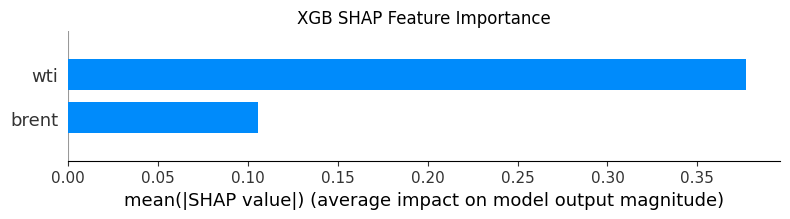

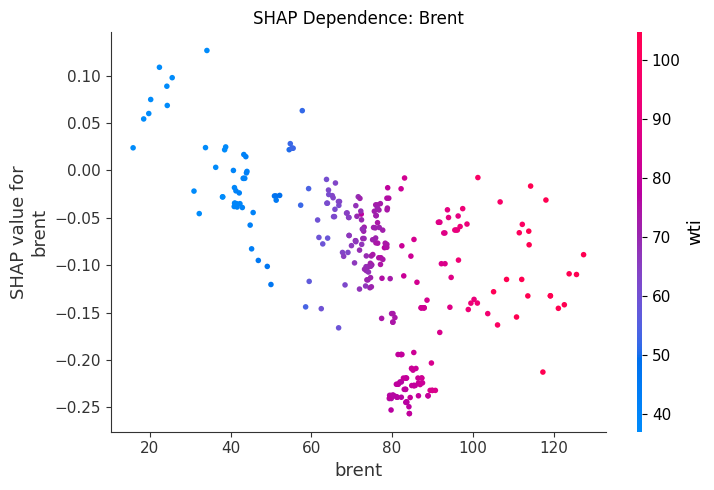

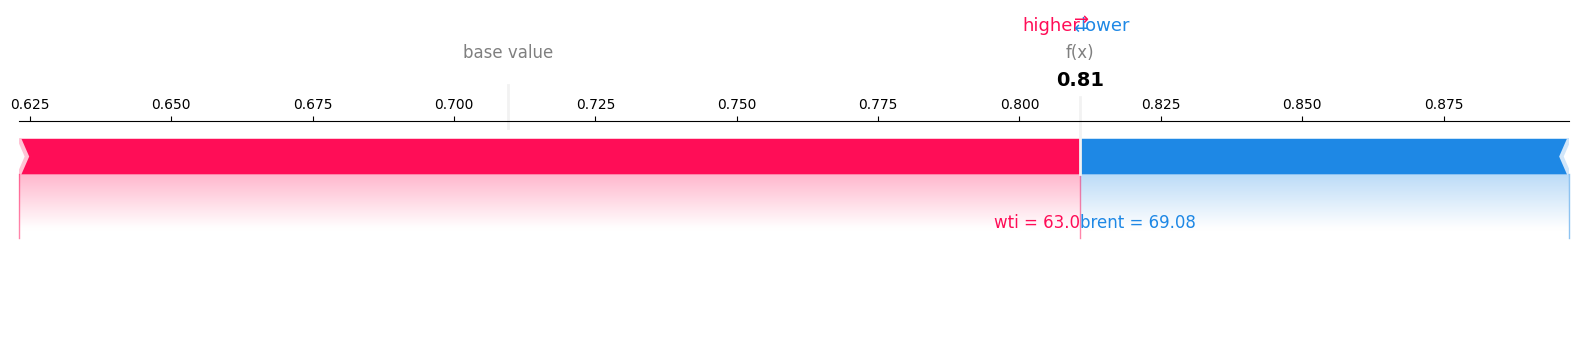

<Figure size 640x480 with 0 Axes>

✔️ SHAP plots saved: xgb_shap_importance.png, xgb_shap_dependence_brent.png, xgb_shap_force_0.png


In [4]:

import shap
from xgboost import XGBRegressor


train_end = '2019-12-27'
X_train = ex.loc[:train_end]
y_train = y.loc[:train_end]
X_test  = ex.loc['2020-01-03':]

gx_model = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
gx_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(gx_model)
shap_values = explainer.shap_values(X_test)

#  Global importance bar
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('XGB SHAP Feature Importance')
plt.tight_layout()
plt.savefig(root / 'xgb_shap_importance.png', dpi=300)
plt.show()

# Dependence plot for Brent
shap.dependence_plot('brent', shap_values, X_test, show=False)
plt.title('SHAP Dependence: Brent')
plt.tight_layout()
plt.savefig(root / 'xgb_shap_dependence_brent.png', dpi=300)
plt.show()

# Force plot for the first test instance
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0], matplotlib=True)
plt.savefig(root / 'xgb_shap_force_0.png', dpi=300)
plt.show()

print(" SHAP plots saved: xgb_shap_importance.png, xgb_shap_dependence_brent.png, xgb_shap_force_0.png")


In [8]:
import shap, joblib, pandas as pd, matplotlib.pyplot as plt
xgb = joblib.load('lpg_xgboost_model.pkl')
X_hold = pd.read_csv('lpg_xgboost_predictions.csv', index_col=0)   # whatever you used
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_hold)

shap.summary_plot(shap_values, X_hold, show=False)
plt.savefig('xgb_shap_summary.png', dpi=300)

i = 0
shap.plots.waterfall(shap_values[i], show=False)
plt.savefig('xgb_shap_waterfall_i0.png', dpi=300)


XGBoostError: [09:14:08] C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api_utils.h:129: Check failed: std::accumulate(shape.cbegin(), shape.cend(), static_cast<bst_ulong>(1), std::multiplies<>{}) == chunksize * rows (578 vs. 2312) : 

# LSTM Permutation

Loaded saved LSTM model from lpg_lstm_model.h5
LSTM MAE: 0.048 USD/gal, MAPE: 6.18%
✅ Saved LSTM predictions to lpg_lstm_predictions.csv


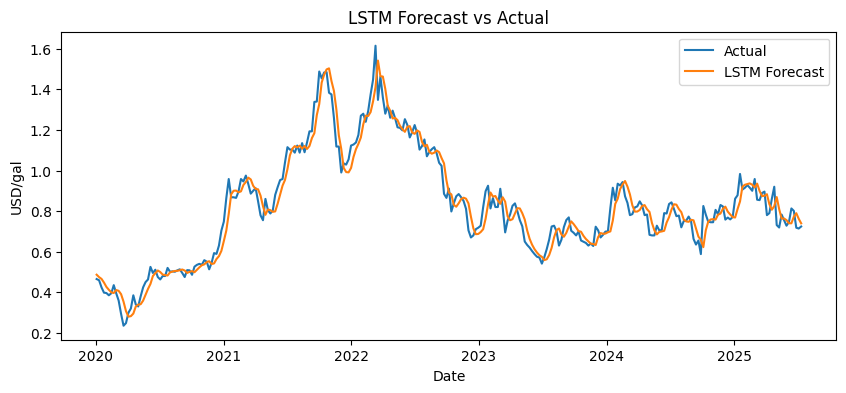

✔️ LSTM model complete.
Loaded saved LSTM model from lpg_lstm_model.h5
Baseline MAE (no shuffle): 0.0476


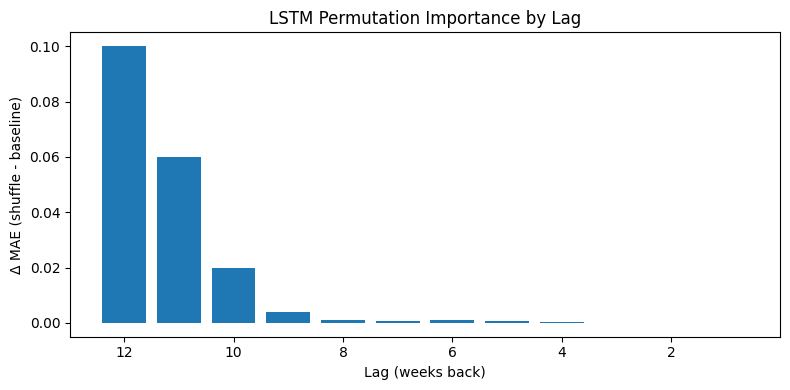

✔️ LSTM permutation importance complete. Files saved:
  - lstm_permutation_importance_lags.csv
  - lstm_perm_importance_lags.png


In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py first.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
y = df['lpg_price'].resample('W-FRI').last().dropna().to_frame()


scaler = MinMaxScaler()
scaled = scaler.fit_transform(y)

def create_sequences(data, lookback=12):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        Y.append(data[i])
    return np.array(X), np.array(Y)


lookback = 12
X, Y = create_sequences(scaled, lookback)

split = np.where(y.index >= '2020-01-01')[0][0] - lookback
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

MODEL_PATH = Path('lpg_lstm_model.h5')
if MODEL_PATH.exists():
    from tensorflow.keras.models import load_model
    model = load_model(MODEL_PATH)
    print("Loaded saved LSTM model from lpg_lstm_model.h5")
else:
    raise FileNotFoundError("lpg_lstm_model.h5 not found. Train the LSTM once in a separate script, save it as lpg_lstm_model.h5, then rerun this notebook.")

# Forecast (using loaded or trained model) 
pred_scaled = model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled)
actual = y.values[lookback+split:]

mae = mean_absolute_error(actual, pred)
mape = mean_absolute_percentage_error(actual, pred) * 100
print(f"LSTM MAE: {mae:.3f} USD/gal, MAPE: {mape:.2f}%")

pred_index = y.index[lookback+split:]
pred_df = pd.DataFrame({'forecast': pred.flatten()}, index=pred_index)
pred_df.to_csv('lpg_lstm_predictions.csv')
print("Saved LSTM predictions to lpg_lstm_predictions.csv")

plt.figure(figsize=(10,4))
plt.plot(pred_index, actual, label='Actual')
plt.plot(pred_index, pred, label='LSTM Forecast')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.show()

print("✔️ LSTM model complete.")

# Permutation Importance for LSTM (no retrain)

from tensorflow.keras.models import load_model
if Path('lpg_lstm_model.h5').exists():
    try:
        model = load_model('lpg_lstm_model.h5')
        print("Loaded saved LSTM model from lpg_lstm_model.h5")
    except Exception as e:
        print("Could not load saved LSTM model, using current model:", e)

# Helper to get inverse-scaled predictions
def predict_inverse(X_arr):
    pred_scaled = model.predict(X_arr, verbose=0)
    return scaler.inverse_transform(pred_scaled)

# Inverse-scale ground truth
actual_inv = scaler.inverse_transform(Y_test)

baseline_mae = mean_absolute_error(actual_inv, predict_inverse(X_test))
print(f"Baseline MAE (no shuffle): {baseline_mae:.4f}")

lookback = X_test.shape[1]
lag_importance = []

for t in range(lookback):
    X_perm = X_test.copy()
    shuffle_idx = np.random.permutation(X_perm.shape[0])
    X_perm[:, t, 0] = X_perm[shuffle_idx, t, 0]
    mae_perm = mean_absolute_error(actual_inv, predict_inverse(X_perm))
    lag_importance.append(mae_perm - baseline_mae)

lag_df = pd.DataFrame({
    'lag_week_back': list(range(lookback, 0, -1)),
    'delta_mae': lag_importance[::-1]  
})
lag_df.to_csv('lstm_permutation_importance_lags.csv', index=False)


plt.figure(figsize=(8,4))
plt.bar(lag_df['lag_week_back'], lag_df['delta_mae'])
plt.gca().invert_xaxis()
plt.xlabel('Lag (weeks back)')
plt.ylabel('Δ MAE (shuffle - baseline)')
plt.title('LSTM Permutation Importance by Lag')
plt.tight_layout()
plt.savefig('lstm_perm_importance_lags.png', dpi=300)
plt.show()

print(""" LSTM permutation importance complete. Files saved:
  - lstm_permutation_importance_lags.csv
  - lstm_perm_importance_lags.png""")


# Permutation with reapeted shuffle and CI bands

Loaded saved LSTM model from lpg_lstm_model.h5
LSTM MAE: 0.048 USD/gal, MAPE: 6.18%
 Saved LSTM predictions to lpg_lstm_predictions.csv


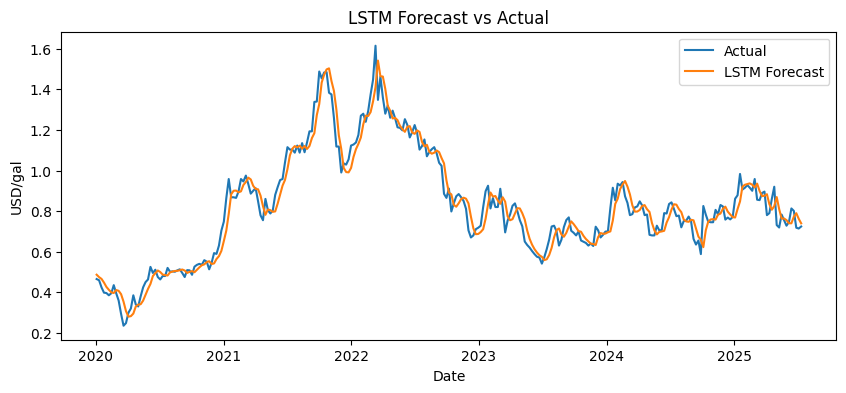

✔️ LSTM model complete.
Loaded saved LSTM model from lpg_lstm_model.h5
Baseline MAE (no shuffle): 0.0476


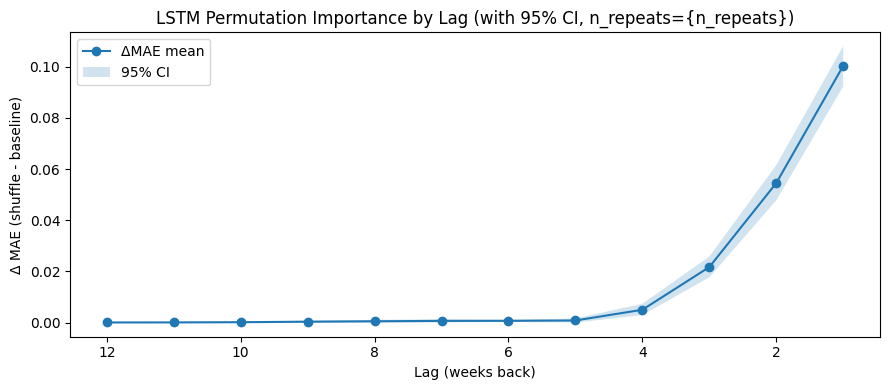

 LSTM permutation importance complete. Files saved:
  - lstm_permutation_importance_lags.csv
  - lstm_perm_importance_lags.png


In [18]:
DATA_FILE = Path("lpg_dataset.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError("Run lpg_dataset_collector.py first.")

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
y = df['lpg_price'].resample('W-FRI').last().dropna().to_frame()

scaler = MinMaxScaler()
scaled = scaler.fit_transform(y)

def create_sequences(data, lookback=12):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        Y.append(data[i])
    return np.array(X), np.array(Y)

lookback = 12
X, Y = create_sequences(scaled, lookback)

split = np.where(y.index >= '2020-01-01')[0][0] - lookback
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

MODEL_PATH = Path('lpg_lstm_model.h5')
if MODEL_PATH.exists():
    from tensorflow.keras.models import load_model
    model = load_model(MODEL_PATH)
    print("Loaded saved LSTM model from lpg_lstm_model.h5")
else:
    raise FileNotFoundError("lpg_lstm_model.h5 not found.")

pred_scaled = model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled)
actual = y.values[lookback+split:]

mae = mean_absolute_error(actual, pred)
mape = mean_absolute_percentage_error(actual, pred) * 100
print(f"LSTM MAE: {mae:.3f} USD/gal, MAPE: {mape:.2f}%")

pred_index = y.index[lookback+split:]
pred_df = pd.DataFrame({'forecast': pred.flatten()}, index=pred_index)
pred_df.to_csv('lpg_lstm_predictions.csv')
print(" Saved LSTM predictions to lpg_lstm_predictions.csv")

plt.figure(figsize=(10,4))
plt.plot(pred_index, actual, label='Actual')
plt.plot(pred_index, pred, label='LSTM Forecast')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('USD/gal')
plt.legend()
plt.show()

print("✔️ LSTM model complete.")


from tensorflow.keras.models import load_model
if Path('lpg_lstm_model.h5').exists():
    try:
        model = load_model('lpg_lstm_model.h5')
        print("Loaded saved LSTM model from lpg_lstm_model.h5")
    except Exception as e:
        print("Could not load saved LSTM model, using current model:", e)

def predict_inverse(X_arr):
    pred_scaled = model.predict(X_arr, verbose=0)
    return scaler.inverse_transform(pred_scaled)

actual_inv = scaler.inverse_transform(Y_test)

# Baseline MAE on untouched data 
baseline_mae = mean_absolute_error(actual_inv, predict_inverse(X_test))
print(f"Baseline MAE (no shuffle): {baseline_mae:.4f}")

# Permutation importance with repeated shuffles & confidence bands

n_repeats = 200  
lookback = X_test.shape[1]
all_deltas = np.zeros((lookback, n_repeats)) 

rng = np.random.default_rng(42)
for t in range(lookback):
    for r in range(n_repeats):
        X_perm = X_test.copy()
        shuffle_idx = rng.permutation(X_perm.shape[0])
        X_perm[:, t, 0] = X_perm[shuffle_idx, t, 0]
        mae_perm = mean_absolute_error(actual_inv, predict_inverse(X_perm))
        all_deltas[t, r] = mae_perm - baseline_mae

# Stats
mean_delta = all_deltas.mean(axis=1)
std_delta  = all_deltas.std(axis=1, ddof=1)
ci_low, ci_high = np.percentile(all_deltas, [2.5, 97.5], axis=1)

lag_numbers = np.arange(lookback, 0, -1) 
lag_df = pd.DataFrame({
    'lag_week_back': lag_numbers,
    'delta_mae_mean': mean_delta[::-1],
    'delta_mae_std':  std_delta[::-1],
    'ci_low':         ci_low[::-1],
    'ci_high':        ci_high[::-1]
})
lag_df.to_csv('lstm_permutation_importance_lags.csv', index=False)

# Plot with CI bands
plt.figure(figsize=(9,4))
plt.plot(lag_numbers, mean_delta, marker='o', label='ΔMAE mean')
plt.fill_between(lag_numbers, ci_low, ci_high, alpha=0.2, label='95% CI')
plt.gca().invert_xaxis()
plt.xlabel('Lag (weeks back)')
plt.ylabel('Δ MAE (shuffle - baseline)')
plt.title('LSTM Permutation Importance by Lag (with 95% CI, n_repeats={n_repeats})')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_perm_importance_lags.png', dpi=300)
plt.show()

print(""" LSTM permutation importance complete. Files saved:
  - lstm_permutation_importance_lags.csv
  - lstm_perm_importance_lags.png""")


In [2]:
# integrated_gradients_lstm.py
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tf_keras_vis.integrated_gradients import IntegratedGradients
from tf_keras_vis.utils.scores import Score

model = load_model('lpg_lstm_model.h5')

def model_fn(inputs):
    return model(inputs).numpy()

score = Score(lambda out: out[:,0])  # single output
ig = IntegratedGradients(model_fn)

x_sample = X_test[:50]  # small batch to visualize
attributions = ig(score, x_sample, steps=64)
attr_mean = np.mean(np.abs(attributions), axis=0)[:,0]  # (lookback,)

plt.figure(figsize=(7,3))
plt.bar(range(lookback,0,-1), attr_mean[::-1])
plt.xlabel('Lag (weeks back)'); plt.ylabel('|IG| mean')
plt.title('LSTM Integrated Gradients by Lag')
plt.tight_layout(); plt.savefig('lstm_ig_lags.png', dpi=300)


ModuleNotFoundError: No module named 'tf_keras_vis.integrated_gradients'

# SARIMAX — coefficient

                                     SARIMAX Results                                      
Dep. Variable:                          lpg_price   No. Observations:                 1434
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                2248.581
Date:                            Thu, 24 Jul 2025   AIC                          -4483.162
Time:                                    04:35:31   BIC                          -4446.827
Sample:                                07-10-1992   HQIC                         -4469.543
                                     - 12-27-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
brent          0.0065      0.001      7.974      0.000       0.005       0.008
wti            0.0031      0.001   

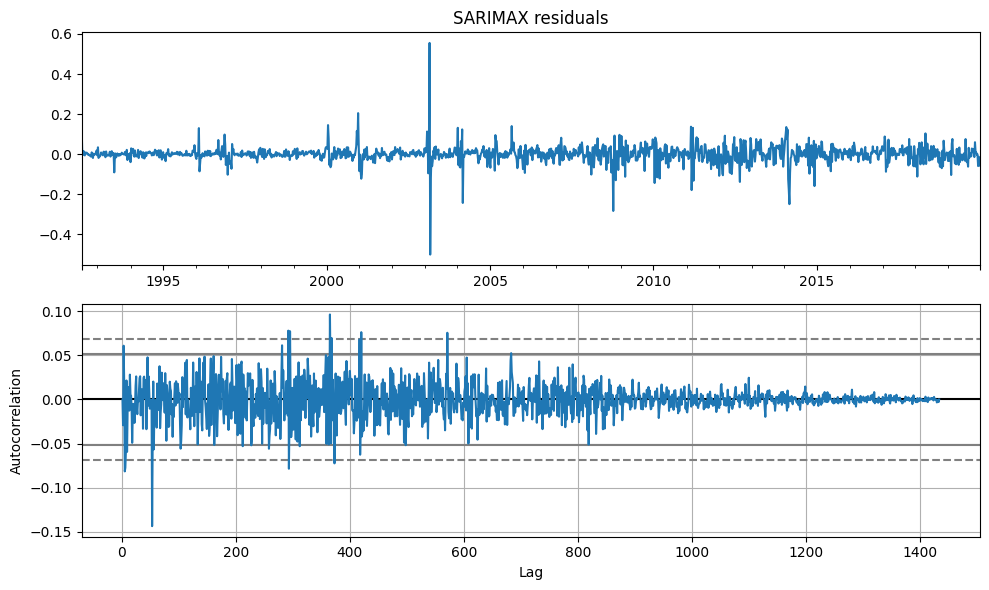

In [4]:
import pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
from statsmodels.stats.diagnostic import acorr_ljungbox

m = SARIMAXResults.load('lpg_sarimax_model.pkl')   
print(m.summary())

# Residual diagnostics
resid = m.resid
lb = acorr_ljungbox(resid, lags=[12,24], return_df=True)
print(lb)

fig, ax = plt.subplots(2,1, figsize=(10,6))
resid.plot(ax=ax[0], title='SARIMAX residuals')
pd.plotting.autocorrelation_plot(resid, ax=ax[1])
plt.tight_layout(); plt.savefig('sarimax_residual_diagnostics.png', dpi=300)


# Prophet Direct inter pretability

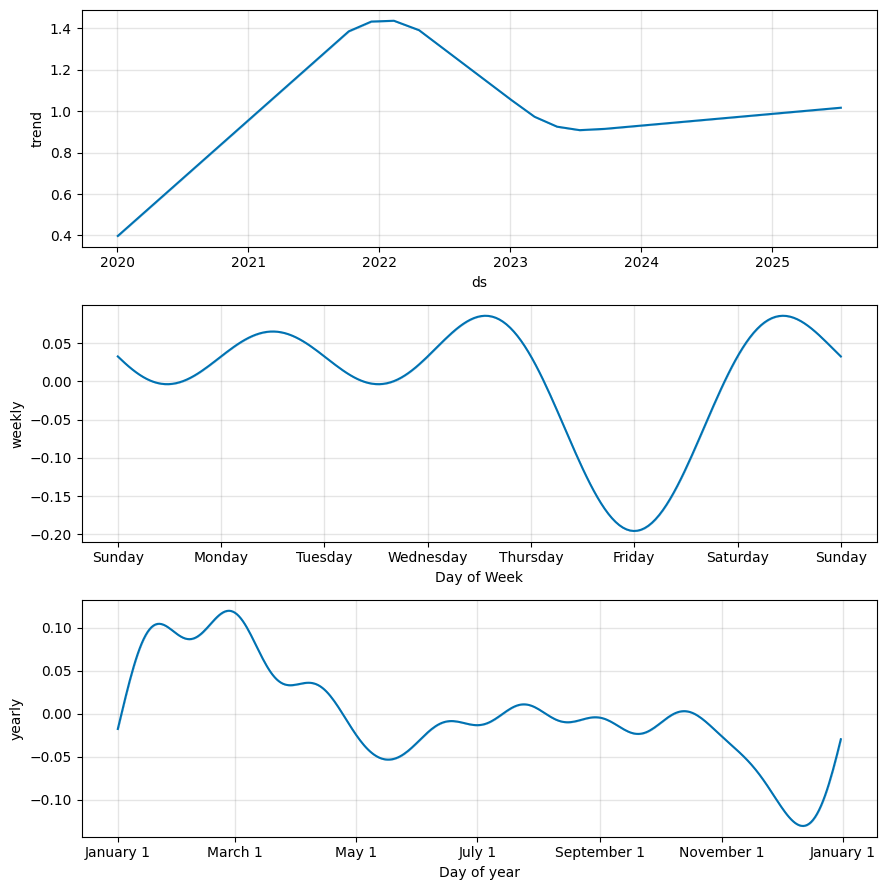

In [20]:
from prophet import Prophet
import joblib, matplotlib.pyplot as plt

prophet_model = joblib.load('lpg_prophet_model.pkl')
forecast = prophet_model.predict(prophet_model.history[['ds']])
fig = prophet_model.plot_components(forecast)
fig.savefig('prophet_components.png', dpi=300)


# ridge stack


In [3]:
import joblib, pandas as pd
stack = joblib.load('lpg_ridge_stack_model.pkl')
coef = pd.Series(stack.coef_, index=['sarimax','lstm','xgb'])
print("Weights:\n", coef, "\nIntercept:", stack.intercept_)
coef.to_csv('ridge_stack_weights.csv')


Weights:
 sarimax   -0.090579
lstm      -0.069738
xgb        1.113623
dtype: float64 
Intercept: -0.001531497955583383


# 

# Emperical VaR

Saved forecast errors: lpg_errors.csv
Saved VaR summary: lpg_var_summary.csv
Saved error distribution plot: lpg_error_distributions.png


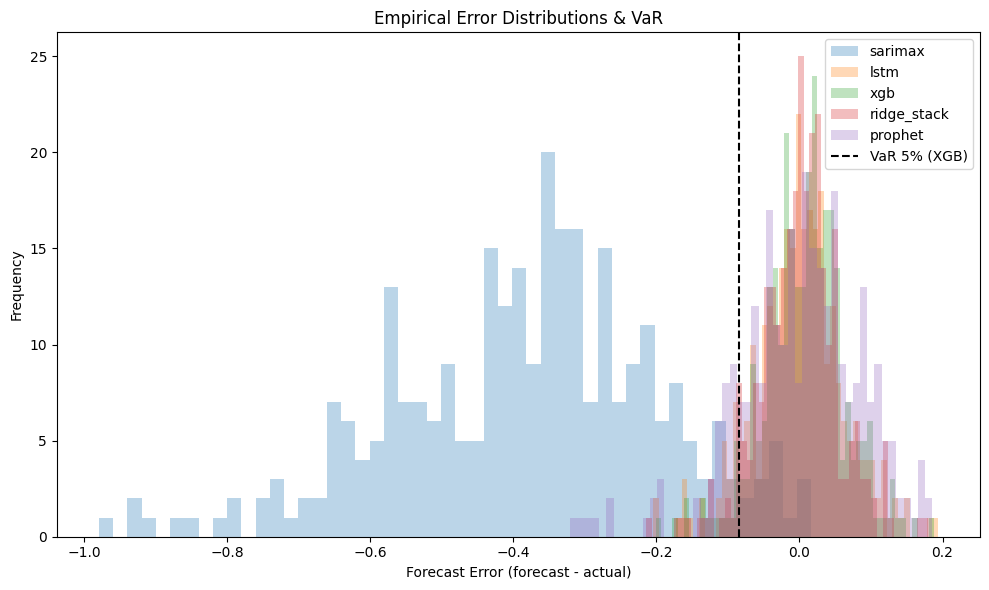

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

root = Path('.')
# Load actual weekly LPG prices
df = pd.read_csv(root / 'lpg_dataset.csv', index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last().dropna().to_frame(name='actual')

# Models to analyze
models = ['sarimax', 'lstm', 'xgb', 'ridge_stack', 'prophet']
# Load each model's predictions
preds = {}
for m in models:
    path = root / f'lpg_{m}_predictions.csv'
    if path.exists():
        preds[m] = (pd.read_csv(path, index_col=0, parse_dates=True)
                     .rename(columns={'forecast': m})[m])
    else:
        raise FileNotFoundError(f"Missing prediction file: {path}")

errors_df = actual.copy()
for m, series in preds.items():
    # align by inner join
    errors_df = errors_df.join(series, how='inner')
# Compute forecast error: forecast minus actual
for m in models:
    errors_df[f'err_{m}'] = errors_df[m] - errors_df['actual']

errors_cols = [f'err_{m}' for m in models]
errors_df[errors_cols].to_csv(root / 'lpg_errors.csv')
print("Saved forecast errors: lpg_errors.csv")


var_results = []
for m in models:
    errs = errors_df[f'err_{m}']
    q5  = np.percentile(errs, 5)    
    q95 = np.percentile(errs, 95)   
    var_results.append({'model': m,
                        'VaR_5%': q5,
                        'VaR_95%': q95,
                        'mean_error': errs.mean(),
                        'std_error': errs.std()})
var_df = pd.DataFrame(var_results)
var_df.to_csv(root / 'lpg_var_summary.csv', index=False)
print("Saved VaR summary: lpg_var_summary.csv")

# Plot error distributions 
plt.figure(figsize=(10,6))
for m in models:
    errs = errors_df[f'err_{m}']
    plt.hist(errs, bins=50, alpha=0.3, label=m)
plt.axvline(np.percentile(errors_df['err_xgb'],5), color='k', linestyle='--', label='VaR 5% (XGB)')
plt.xlabel('Forecast Error (forecast - actual)')
plt.ylabel('Frequency')
plt.title('Empirical Error Distributions & VaR')
plt.legend()
plt.tight_layout()
plt.savefig(root / 'lpg_error_distributions.png', dpi=300)
print("Saved error distribution plot: lpg_error_distributions.png")
plt.show()

# bootStrap VaR 

Saved forecast errors: lpg_errors.csv
Saved empirical VaR summary: lpg_var_summary.csv
Saved bootstrap VaR summary: lpg_var_bootstrap.csv
 Saved error distribution plot: lpg_error_distributions.png
Saved bootstrap VaR CI plot: lpg_var_bootstrap_ci.png


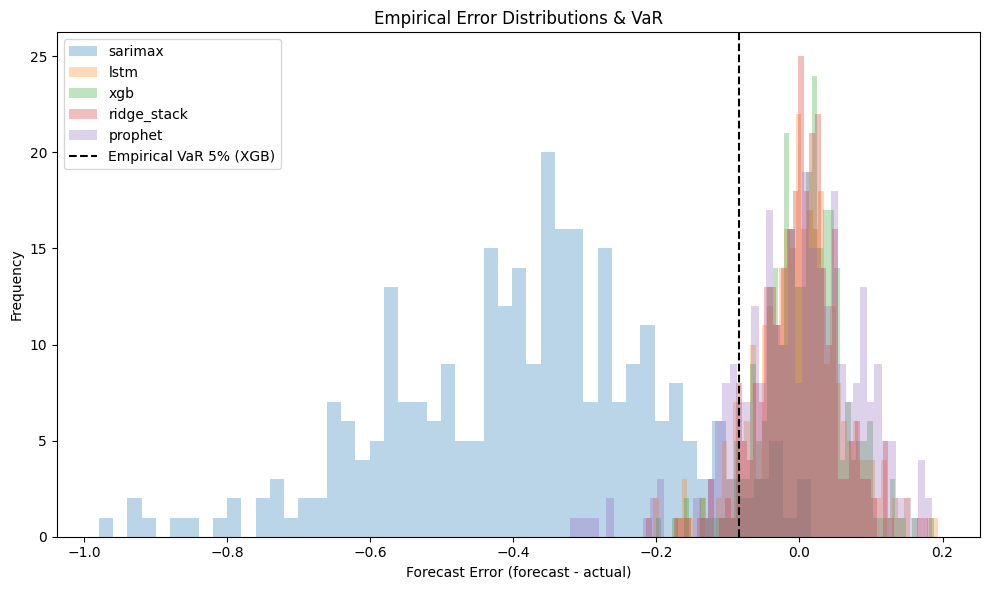

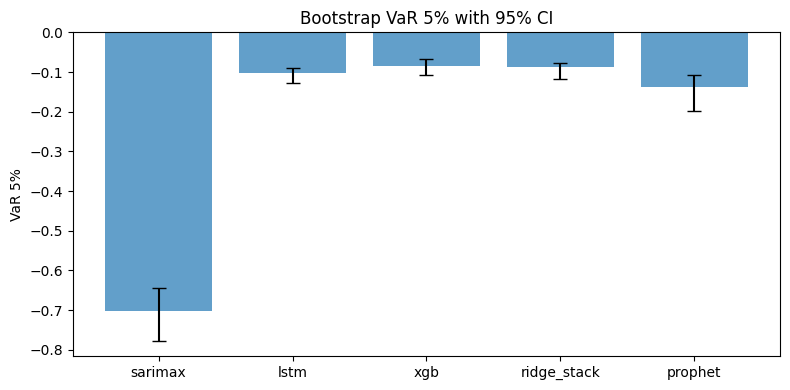

In [5]:
root = Path('.')
kf = root / 'lpg_dataset.csv'
df = pd.read_csv(kf, index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last().dropna().to_frame(name='actual')

models = ['sarimax', 'lstm', 'xgb', 'ridge_stack', 'prophet']
preds = {}
for m in models:
    path = root / f'lpg_{m}_predictions.csv'
    if path.exists():
        preds[m] = (
            pd.read_csv(path, index_col=0, parse_dates=True)
              .rename(columns={'forecast': m})[m]
        )
    else:
        raise FileNotFoundError(f"Missing prediction file: {path}")

errors_df = actual.copy()
for m, series in preds.items():
    errors_df = errors_df.join(series, how='inner')
# Compute forecast error: forecast minus actual
for m in models:
    errors_df[f'err_{m}'] = errors_df[m] - errors_df['actual']

errors_cols = [f'err_{m}' for m in models]
errors_df[errors_cols].to_csv(root / 'lpg_errors.csv')
print("Saved forecast errors: lpg_errors.csv")

# Compute empirical VaR (quantiles)
var_results = []
for m in models:
    errs = errors_df[f'err_{m}']
    q5  = np.percentile(errs, 5)    # 5th percentile
    q95 = np.percentile(errs, 95)   # 95th percentile
    var_results.append({
        'model': m,
        'VaR_5%': q5,
        'VaR_95%': q95,
        'mean_error': errs.mean(),
        'std_error': errs.std()
    })
var_df = pd.DataFrame(var_results)
var_df.to_csv(root / 'lpg_var_summary.csv', index=False)
print("Saved empirical VaR summary: lpg_var_summary.csv")

# Bootstrap VaR with 95% CI 
np.random.seed(42)
boot_results = []
B = 1000            
alpha = 5            # percentile for VaR (5%)
for m in models:
    errs = errors_df[f'err_{m}'].values
    boot_q = []
    for _ in range(B):
        sample = np.random.choice(errs, size=len(errs), replace=True)
        boot_q.append(np.percentile(sample, alpha))
    boot_q = np.array(boot_q)
    ci_low, ci_high = np.percentile(boot_q, [2.5, 97.5])
    boot_results.append({
        'model': m,
        'VaR_5%_boot_mean': np.mean(boot_q),
        'VaR_5%_boot_ci_low': ci_low,
        'VaR_5%_boot_ci_high': ci_high
    })
boot_df = pd.DataFrame(boot_results)
boot_df.to_csv(root / 'lpg_var_bootstrap.csv', index=False)
print("Saved bootstrap VaR summary: lpg_var_bootstrap.csv")

# error distributions & empirical VaR plot
plt.figure(figsize=(10,6))
for m in models:
    errs = errors_df[f'err_{m}']
    plt.hist(errs, bins=50, alpha=0.3, label=m)
# empirical VaR for one model as reference 
plt.axvline(var_df[var_df.model=='xgb']['VaR_5%'].iloc[0],
            color='k', linestyle='--', label='Empirical VaR 5% (XGB)')
plt.xlabel('Forecast Error (forecast - actual)')
plt.ylabel('Frequency')
plt.title('Empirical Error Distributions & VaR')
plt.legend()
plt.tight_layout()
plt.savefig(root / 'lpg_error_distributions.png', dpi=300)
print(" Saved error distribution plot: lpg_error_distributions.png")

#  bootstrap VaR CI bands  plot
plt.figure(figsize=(8,4))
indices = np.arange(len(models))
means = boot_df['VaR_5%_boot_mean']
ci_low = boot_df['VaR_5%_boot_ci_low']
ci_high = boot_df['VaR_5%_boot_ci_high']  # CI upper bound
ci_err = [means - ci_low, ci_high - means]

plt.bar(indices, means, yerr=ci_err, capsize=5, alpha=0.7)
plt.xticks(indices, models)
plt.ylabel('VaR 5%')
plt.title('Bootstrap VaR 5% with 95% CI')
plt.tight_layout()
plt.savefig(root / 'lpg_var_bootstrap_ci.png', dpi=300)
print("Saved bootstrap VaR CI plot: lpg_var_bootstrap_ci.png")
# Show the plot
plt.show()


# empirical_var at 5%

✔️ Parametric VaR saved: lpg_var_parametric.csv
               VaR_5%
sarimax     -0.691894
lstm        -0.104840
xgb         -0.086189
ridge_stack -0.090844
prophet     -0.143934 



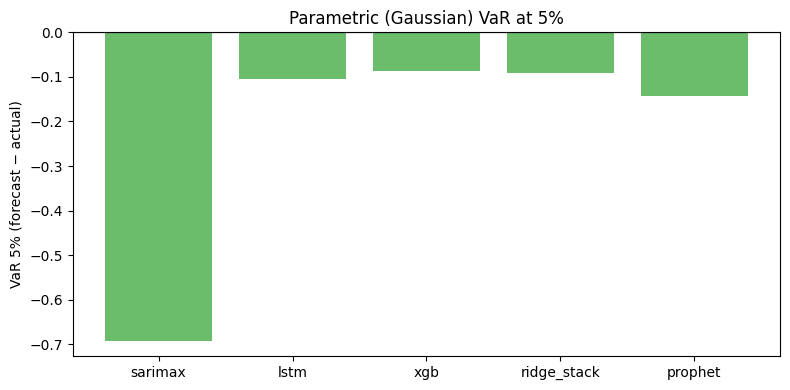

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

root = Path('.')
# 1. Load actual and predictions
df = pd.read_csv(root / 'lpg_dataset.csv', index_col=0, parse_dates=True)
actual = df['lpg_price'].resample('W-FRI').last().dropna()

models = ['sarimax','lstm','xgb','ridge_stack','prophet']
preds = {}
for m in models:
    pth = root / f'lpg_{m}_predictions.csv'
    if not pth.exists():
        raise FileNotFoundError(f"Missing forecast file: {pth}")
    preds[m] = (pd.read_csv(pth, index_col=0, parse_dates=True)
                  .rename(columns={'forecast':m})[m])

# 2. Align into one DataFrame
df_all = pd.concat([actual.rename('actual')] + [preds[m] for m in models], axis=1).dropna()
df_all.columns = ['actual'] + models

# 3. Compute errors: forecast minus actual
errors = df_all[models].subtract(df_all['actual'], axis=0)

# 4. Parametric VaR (Gaussian) at α=5%
alpha = 0.05
z = norm.ppf(alpha)  # ≈ -1.645 for 5% one-sided
parametric = {}
for m in models:
    mu    = errors[m].mean()
    sigma = errors[m].std(ddof=1)
    parametric[m] = mu + sigma * z

param_df = pd.Series(parametric, name='VaR_5%').to_frame()
param_df.to_csv(root / 'lpg_var_parametric.csv')
print("✔️ Parametric VaR saved: lpg_var_parametric.csv")
print(param_df, "\n")

# 5. Plot comparison
x = np.arange(len(models))
plt.figure(figsize=(8,4))
plt.bar(x, param_df['VaR_5%'], color='C2', alpha=0.7)
plt.xticks(x, models)
plt.axhline(0, color='k', linewidth=0.8)
plt.ylabel('VaR 5% (forecast − actual)')
plt.title('Parametric (Gaussian) VaR at 5%')
plt.tight_layout()
plt.savefig(root / 'lpg_var_parametric_plot.png', dpi=300)
plt.show()
